In [1]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
source_path = '/Users/harryclark/Downloads/COHORT12/'
locations = pd.read_csv('/Users/harryclark/Downloads/all_cluster_brain_locations_chris.csv')
locations['coord_SCs_x'] = locations['coord_SCs_x'] * -1


# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }


In [2]:

# --- Extract task-anchoring labels and compute abundance for all GCS and NGS cells ---
all_gcs_dfs = []
all_ngs_dfs = []

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")

        try:
            gcs, ngs, all = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Failed to load Mouse {mouse} Day {day}: {e}")
            continue

        print(f'  {len(gcs)} GCS cells, {len(ngs)} NGS cells, {len(all)} total cells')

        for cell_type, cell_df in [('GCS', gcs), ('NGS', ngs)]:
            if cell_df.empty:
                print(f"    No {cell_type} cells for Mouse {mouse} Day {day}, skipping.")
                continue
            
            abundances = []
            for cluster_id in cell_df.cluster_id.values:
                try:
                    tc = tcs[cluster_id] if cluster_id in tcs else None
                    if tc is None:
                        abundances.append(np.nan)
                        continue
                    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
                    tc = tc[:last_ephys_bin]
                    tcs_to_use = {cluster_id: tc, 1000: tc}

                    results = spectral_analysis(tcs_to_use, tl, bs=bs)
                    spectrograms = results[3]
                    S = spectrograms.mean(0)
                    max_peaks = np.argmax(S, axis=0)
                    labels_indices = np.isin(max_peaks, [12, 28, 44, 60, 76]).astype(int)
                    labels = get_kmeans_spatial_labels(tc, labels_indices, bs=bs, tl=tl)

                    n_total = len(labels)
                    n_anchored = int(np.sum(labels == 1))
                    abundances.append(n_anchored / n_total if n_total > 0 else np.nan)

                except Exception as e:
                    print(f"    Error processing {cell_type} cluster {cluster_id}: {e}")
                    abundances.append(np.nan)

            out = cell_df.copy()
            out['mouse'] = mouse
            out['day'] = day
            out['task_anchoring_abundance'] = abundances

            if cell_type == 'GCS':
                all_gcs_dfs.append(out)
            else:
                all_ngs_dfs.append(out)

all_gcs = pd.concat(all_gcs_dfs, ignore_index=True)
all_ngs = pd.concat(all_ngs_dfs, ignore_index=True)

print(f"\nDone. {len(all_gcs)} GCS cells, {len(all_ngs)} NGS cells.")
all_gcs.head()


Processing Mouse 20 Day 14...
  4 GCS cells, 109 NGS cells, 199 total cells
Processing Mouse 20 Day 15...
  3 GCS cells, 50 NGS cells, 65 total cells
Processing Mouse 20 Day 16...
  11 GCS cells, 165 NGS cells, 209 total cells
    Error processing NGS cluster 234: all input arrays must have the same shape
Processing Mouse 20 Day 17...
  3 GCS cells, 70 NGS cells, 107 total cells
Processing Mouse 20 Day 18...
  4 GCS cells, 105 NGS cells, 133 total cells
Processing Mouse 20 Day 19...
  1 GCS cells, 91 NGS cells, 108 total cells
    Error processing NGS cluster 186: all input arrays must have the same shape
    Error processing NGS cluster 401: all input arrays must have the same shape
Processing Mouse 20 Day 20...
  8 GCS cells, 88 NGS cells, 99 total cells
Processing Mouse 20 Day 21...
  1 GCS cells, 70 NGS cells, 107 total cells
Processing Mouse 20 Day 22...
  0 GCS cells, 61 NGS cells, 66 total cells
    No GCS cells for Mouse 20 Day 22, skipping.
Processing Mouse 20 Day 23...
  5 GC

,cluster_id,brain_region,grid_score,field_size,field_spacing,orientation,_smooth_sigma,travel,sig,null_grid_score,...,SC_y,SC_z,probe_x,probe_y,theta_index,firing_rate,firing_rate_OF1,firing_rate_VR,classified_by,task_anchoring_abundance
0,34,ENTm1,-0.370568,40.728949,54.305265,28.178439,1.5,2,False,None,...,3934.027955,4133.233125,32.0,420.0,0.118707,0.727574,0.981535,0.581641,OF2,0.357143
1,103,ENTm1,-0.140560,58.812343,78.416458,15.687386,1.5,2,False,None,...,4166.694770,4229.148339,282.0,195.0,0.108031,5.560003,4.700296,5.677694,OF2,0.589286
2,400,ENTm3,-0.186061,36.455207,48.606943,15.708574,1.5,2,False,None,...,3816.513778,4195.999003,750.0,540.0,0.024564,2.039704,3.905484,0.455483,OF2,0.133929
3,412,ENTm5,0.440898,22.391733,29.855644,25.110225,1.5,2,True,None,...,3741.751806,4201.968554,750.0,615.0,0.029944,6.536149,6.936840,7.255499,OF1,0.267857
4,86,ENTm2,-0.403523,57.065202,76.086936,14.616632,1.5,3,False,None,...,3597.824826,4265.022934,250.0,765.0,0.106741,19.445531,15.085368,25.453392,OF2,0.119403


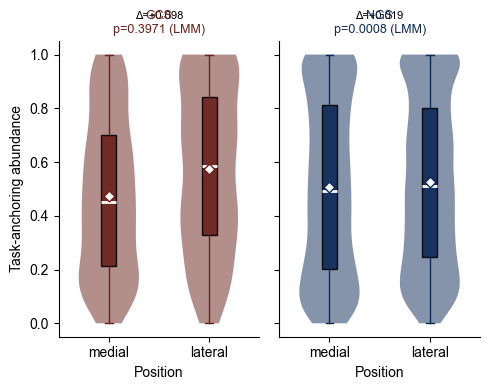

In [3]:

from scipy.stats import mannwhitneyu
import statsmodels.formula.api as smf

all_gcs['SC_x'] = np.abs(all_gcs['SC_x'])
all_ngs['SC_x'] = np.abs(all_ngs['SC_x'])
all_gcs['medial_lateral'] = np.where(all_gcs['SC_x'] < 3400, 'medial', 'lateral')
all_ngs['medial_lateral'] = np.where(all_ngs['SC_x'] < 3400, 'medial', 'lateral')

all_gcs['cell_type'] = 'GCS'
all_ngs['cell_type'] = 'NGS'
plot_df = pd.concat([all_gcs, all_ngs], ignore_index=True).dropna(
    subset=['task_anchoring_abundance', 'medial_lateral', 'mouse', 'day']
)
plot_df['mouse_day'] = plot_df['mouse'].astype(str) + '_' + plot_df['day'].astype(str)
plot_df['position_code'] = (plot_df['medial_lateral'] == 'lateral').astype(float)

cell_types = ['GCS', 'NGS']
positions  = ['medial', 'lateral']
colors     = {'GCS': '#69201a', 'NGS': '#0d2958'}

fig, axes = plt.subplots(1, 2, figsize=(5, 4), sharey=True)

for ax, cell_type in zip(axes, cell_types):
    ct_df = plot_df[plot_df['cell_type'] == cell_type].copy()
    color = colors[cell_type]

    group_vals = []
    group_means = []
    for x_pos, position in enumerate(positions):
        vals = ct_df[ct_df['medial_lateral'] == position]['task_anchoring_abundance'].dropna().values
        group_vals.append(vals)
        group_means.append(np.mean(vals))

        # Violin
        parts = ax.violinplot(vals, positions=[x_pos], widths=0.6,
                              showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.5)

        # Box plot overlaid
        ax.boxplot(
            vals, positions=[x_pos], widths=0.15,
            patch_artist=True, showfliers=False,
            medianprops=dict(color='white', linewidth=2),
            boxprops=dict(facecolor=color, alpha=0.9),
            whiskerprops=dict(color=color),
            capprops=dict(color=color),
        )

        # Mean marker
        ax.scatter([x_pos], [group_means[-1]], color='white', s=30, zorder=5, marker='D',
                   edgecolors=color, linewidths=1)

    # Difference of means annotation
    diff = group_means[1] - group_means[0]  # lateral - medial
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else max(np.concatenate(group_vals))
    bracket_y = y_top * 1.05
    ax.annotate('', xy=(1, bracket_y), xytext=(0, bracket_y),
                arrowprops=dict(arrowstyle='-', color='black', lw=1))
    ax.text(0.5, bracket_y * 1.02, f'Δ={diff:+.3f}', ha='center', va='bottom',
            fontsize=8, color='black')

    # Linear mixed model
    try:
        lmm = smf.mixedlm(
            "task_anchoring_abundance ~ position_code",
            data=ct_df,
            groups=ct_df["mouse"],
            vc_formula={"day": "0 + C(day)", "cluster": "0 + C(cluster_id)"},
        )
        res = lmm.fit(reml=False, method='lbfgs')
        p = res.pvalues['position_code']
        ax.set_title(f'{cell_type}\np={p:.4f} (LMM)', fontsize=9, color=color)
    except Exception as e:
        ax.set_title(f'{cell_type}\nLMM error', fontsize=9, color=color)
        print(f'{cell_type} LMM error: {e}')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(positions)
    ax.set_xlabel('Position')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel('Task-anchoring abundance')
plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_abundance_medial_lateral.pdf'
)
plt.show()


In [4]:
# there are all the sessions
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              22: [33,34,35,36,37,38,39,40,41],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41],
    25: [16,17,18,25],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

# --- Three 2x2 task-anchoring agreement matrices ---
# GCS-only, NGS-only, and GCS+NGS pooled.
# Rows/Cols = medial vs lateral.
# Each cell = mean pairwise agreement between same-session cell pairs at those
# positions. Self-pairs (same cluster_id in same session) are excluded.

PEAKS = [12, 28, 44, 60, 76]
POSITIONS = ['medial', 'lateral']

# Build position lookups
gcs_pos_map = {
    (int(r['mouse']), int(r['day']), int(r['cluster_id'])): r['medial_lateral']
    for _, r in all_gcs.iterrows()
}
ngs_pos_map = {
    (int(r['mouse']), int(r['day']), int(r['cluster_id'])): r['medial_lateral']
    for _, r in all_ngs.iterrows()
}
all_cells_df = pd.concat([all_gcs, all_ngs], ignore_index=True)
all_pos_map = {
    (int(r['mouse']), int(r['day']), int(r['cluster_id'])): r['medial_lateral']
    for _, r in all_cells_df.iterrows()
}

# agreement_lists for each group
gcs_agr     = {(pA, pB): [] for pA in POSITIONS for pB in POSITIONS}
ngs_agr     = {(pA, pB): [] for pA in POSITIONS for pB in POSITIONS}
pooled_agr  = {(pA, pB): [] for pA in POSITIONS for pB in POSITIONS}

def _compute_pairwise(cell_labels, agr_dict):
    cell_ids = list(cell_labels.keys())
    for i, cid_a in enumerate(cell_ids):
        lab_a, pos_a = cell_labels[cid_a]
        for cid_b in cell_ids[i + 1:]:
            lab_b, pos_b = cell_labels[cid_b]
            n = min(len(lab_a), len(lab_b))
            if n == 0:
                continue
            agr = np.mean(lab_a[:n] == lab_b[:n])
            agr_dict[(pos_a, pos_b)].append(agr)
            if pos_a != pos_b:
                agr_dict[(pos_b, pos_a)].append(agr)

for mouse, days in mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        try:
            gcs, ngs, all_cells = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Skipping: {e}")
            continue

        def _get_labels(cluster_id):
            tc = tcs.get(cluster_id)
            if tc is None:
                return None
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            results = spectral_analysis({cluster_id: tc, 1000: tc}, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_idx = np.isin(max_peaks, PEAKS).astype(int)
            return get_kmeans_spatial_labels(tc, labels_idx, bs=bs, tl=tl)

        def _build_cell_labels(cids, pos_map):
            cell_labels = {}
            for cid in cids:
                pos = pos_map.get((mouse, day, int(cid)))
                if pos is None:
                    continue
                try:
                    lab = _get_labels(cid)
                    if lab is not None:
                        cell_labels[cid] = (lab, pos)
                except Exception:
                    continue
            return cell_labels

        gcs_labels    = _build_cell_labels(gcs.cluster_id.values, gcs_pos_map)
        ngs_labels    = _build_cell_labels(ngs.cluster_id.values, ngs_pos_map)
        pooled_cids   = np.concatenate([gcs.cluster_id.values, ngs.cluster_id.values])
        pooled_labels = _build_cell_labels(pooled_cids, all_pos_map)

        _compute_pairwise(gcs_labels,    gcs_agr)
        _compute_pairwise(ngs_labels,    ngs_agr)
        _compute_pairwise(pooled_labels, pooled_agr)

# Build the three 2x2 matrices
def _build_matrix(agr_dict):
    matrix = np.full((2, 2), np.nan)
    for r, pos_row in enumerate(POSITIONS):
        for c, pos_col in enumerate(POSITIONS):
            vals = agr_dict[(pos_row, pos_col)]
            if vals:
                matrix[r, c] = np.mean(vals)
    return matrix

matrix_gcs    = _build_matrix(gcs_agr)
matrix_ngs    = _build_matrix(ngs_agr)
matrix_pooled = _build_matrix(pooled_agr)

print("GCS agreement matrix:")
print(matrix_gcs)
print("\nNGS agreement matrix:")
print(matrix_ngs)
print("\nGCS+NGS pooled agreement matrix:")
print(matrix_pooled)

# Plot side-by-side
titles   = ['GCS', 'NGS', 'GCS + NGS']
matrices = [matrix_gcs, matrix_ngs, matrix_pooled]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix, vmin=0.5, vmax=1.0, cmap='RdPu')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(POSITIONS, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(POSITIONS, fontsize=10)
    ax.set_xlabel('Cell position', fontsize=10)
    ax.set_ylabel('Cell position', fontsize=10)
    for r in range(2):
        for c in range(2):
            val = matrix[r, c]
            ax.text(c, r, f'{val:.3f}' if not np.isnan(val) else 'nan',
                    ha='center', va='center', fontsize=11,
                    color='white' if val > 0.75 else 'black')
    plt.colorbar(im, ax=ax, label='Mean agreement', shrink=0.8)
    ax.set_title(f'Task-anchoring agreement\n({title})', fontsize=10)

plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_agreement_matrix.pdf'
)
plt.show()


Processing Mouse 20 Day 14...
Processing Mouse 20 Day 15...
Processing Mouse 20 Day 16...
Processing Mouse 20 Day 17...
Processing Mouse 20 Day 18...
Processing Mouse 20 Day 19...
Processing Mouse 20 Day 20...
Processing Mouse 20 Day 21...
Processing Mouse 20 Day 22...
Processing Mouse 20 Day 23...
Processing Mouse 20 Day 24...
Processing Mouse 20 Day 25...
Processing Mouse 20 Day 26...
Processing Mouse 21 Day 15...
Processing Mouse 21 Day 16...
Processing Mouse 21 Day 17...
Processing Mouse 21 Day 18...
Processing Mouse 21 Day 19...
Processing Mouse 21 Day 20...
Processing Mouse 21 Day 21...
Processing Mouse 21 Day 22...
Processing Mouse 21 Day 23...
Processing Mouse 21 Day 24...
Processing Mouse 21 Day 25...
Processing Mouse 21 Day 26...
Processing Mouse 22 Day 33...
Processing Mouse 22 Day 34...
Processing Mouse 22 Day 35...
Processing Mouse 22 Day 36...
Processing Mouse 22 Day 37...
Processing Mouse 22 Day 38...
Processing Mouse 22 Day 39...


AttributeError: 'DataFrame' object has no attribute 'cluster_id'

In [ ]:
multishank_mouse_days = {
    21: [15,16,17,18,22],
    20: [14,15,16,17,18,19],
    22: [37,38,39,40,41],
    25: [16,17,18,25],
    26: [13,15,16,19,20,21,22],
    27: [18,19,23,24,26],
    28: [16,17,18,23],
    29: [16,17,18,20,23,25],
}

In [ ]:

# --- Three 4x4 task-anchoring agreement matrices (by shank) ---
# GCS-only, NGS-only, and GCS+NGS pooled.
# Rows/Cols = shank 0, 1, 2, 3 (medial to lateral).
# Each cell = mean pairwise agreement between same-session cell pairs on those shanks.
# Self-pairs (same cluster_id in same session) are excluded.

PEAKS  = [12, 28, 44, 60, 76]
SHANKS = [0, 1, 2, 3]

# Build shank lookup maps from the abundance DataFrames (already have shank info via SC_x)
# We need to call reconstruct_shank_id per session, so we build maps on the fly below.

gcs_shank_agr    = {(sA, sB): [] for sA in SHANKS for sB in SHANKS}
ngs_shank_agr    = {(sA, sB): [] for sA in SHANKS for sB in SHANKS}
pooled_shank_agr = {(sA, sB): [] for sA in SHANKS for sB in SHANKS}

def _compute_pairwise_shank(cell_labels, agr_dict):
    cell_ids = list(cell_labels.keys())
    for i, cid_a in enumerate(cell_ids):
        lab_a, shank_a = cell_labels[cid_a]
        for cid_b in cell_ids[i + 1:]:
            lab_b, shank_b = cell_labels[cid_b]
            n = min(len(lab_a), len(lab_b))
            if n == 0:
                continue
            agr = np.mean(lab_a[:n] == lab_b[:n])
            agr_dict[(shank_a, shank_b)].append(agr)
            if shank_a != shank_b:
                agr_dict[(shank_b, shank_a)].append(agr)

for mouse, days in multishank_mouse_days.items():
    for day in days:
        print(f"Processing Mouse {mouse} Day {day}...")
        try:
            gcs, ngs, all_cells = classify_cells_both_sessions(
                mouse=mouse, day=day, percentile_threshold=95, verbose=False
            )
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse, day, apply_zscore=False, apply_guassian_filter=False
            )
        except Exception as e:
            print(f"  Skipping: {e}")
            continue

        # Assign shank IDs
        gcs = reconstruct_shank_id(gcs, mouse, colname='probe_x')
        ngs = reconstruct_shank_id(ngs, mouse, colname='probe_x')

        # Build shank lookup maps for this session
        gcs_shank_map = {int(r['cluster_id']): int(r['shank_id']) for _, r in gcs.iterrows()}
        ngs_shank_map = {int(r['cluster_id']): int(r['shank_id']) for _, r in ngs.iterrows()}
        all_shank_map = {**gcs_shank_map, **ngs_shank_map}

        def _get_labels_sh(cluster_id):
            tc = tcs.get(cluster_id)
            if tc is None:
                return None
            tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
            tc = tc[:last_ephys_bin]
            results = spectral_analysis({cluster_id: tc, 1000: tc}, tl, bs=bs)
            S = results[3].mean(0)
            max_peaks = np.argmax(S, axis=0)
            labels_idx = np.isin(max_peaks, PEAKS).astype(int)
            return get_kmeans_spatial_labels(tc, labels_idx, bs=bs, tl=tl)

        def _build_shank_labels(cids, shank_map):
            cell_labels = {}
            for cid in cids:
                shank = shank_map.get(int(cid))
                if shank is None:
                    continue
                try:
                    lab = _get_labels_sh(cid)
                    if lab is not None:
                        cell_labels[cid] = (lab, shank)
                except Exception:
                    continue
            return cell_labels

        gcs_labels    = _build_shank_labels(gcs.cluster_id.values, gcs_shank_map)
        ngs_labels    = _build_shank_labels(ngs.cluster_id.values, ngs_shank_map)
        pooled_cids   = np.concatenate([gcs.cluster_id.values, ngs.cluster_id.values])
        pooled_labels = _build_shank_labels(pooled_cids, all_shank_map)

        _compute_pairwise_shank(gcs_labels,    gcs_shank_agr)
        _compute_pairwise_shank(ngs_labels,    ngs_shank_agr)
        _compute_pairwise_shank(pooled_labels, pooled_shank_agr)

# Build the three 4x4 matrices
def _build_shank_matrix(agr_dict):
    matrix = np.full((4, 4), np.nan)
    for r, s_row in enumerate(SHANKS):
        for c, s_col in enumerate(SHANKS):
            vals = agr_dict[(s_row, s_col)]
            if vals:
                matrix[r, c] = np.mean(vals)
    return matrix

matrix_gcs_sh    = _build_shank_matrix(gcs_shank_agr)
matrix_ngs_sh    = _build_shank_matrix(ngs_shank_agr)
matrix_pooled_sh = _build_shank_matrix(pooled_shank_agr)

shank_labels = [f'S{s}' for s in SHANKS]
print("GCS shank agreement matrix:")
print(matrix_gcs_sh)
print("\nNGS shank agreement matrix:")
print(matrix_ngs_sh)
print("\nGCS+NGS pooled shank agreement matrix:")
print(matrix_pooled_sh)

# --- Plot ---
titles_sh   = ['GCS', 'NGS', 'GCS + NGS']
matrices_sh = [matrix_gcs_sh, matrix_ngs_sh, matrix_pooled_sh]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, matrix, title in zip(axes, matrices_sh, titles_sh):
    im = ax.imshow(matrix, vmin=0.5, vmax=1.0, cmap='RdPu')
    ax.set_xticks(range(4))
    ax.set_xticklabels(shank_labels, fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(shank_labels, fontsize=9)
    ax.set_xlabel('Shank', fontsize=10)
    ax.set_ylabel('Shank', fontsize=10)
    for r in range(4):
        for c in range(4):
            val = matrix[r, c]
            txt = f'{val:.3f}' if not np.isnan(val) else 'nan'
            ax.text(c, r, txt, ha='center', va='center', fontsize=8,
                    color='white' if (not np.isnan(val) and val > 0.75) else 'black')
    plt.colorbar(im, ax=ax, label='Mean agreement', shrink=0.8)
    ax.set_title(f'Task-anchoring agreement by shank\n({title})', fontsize=9)

plt.tight_layout()
plt.savefig(
    '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/'
    'figure_6_task_anchoring/task_anchoring_shank_agreement_matrix.pdf'
)
plt.show()
